<a href="https://colab.research.google.com/github/eniompw/microgpt/blob/main/microgpt_lite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MicroGPT — Lite (Colab T4 GPU)

Minimal GPT in pure PyTorch with key speed improvements: flash attention, RoPE, `torch.compile`, mixed precision, fused AdamW.

> **Runtime:** Go to **Runtime → Change runtime type → T4 GPU** before running.

## 1. GPU Setup and Library Imports

In [1]:
import os, random, json, math, time
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

random.seed(42); torch.manual_seed(42)  # reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}" + (f" | {torch.cuda.get_device_name(0)}" if device.type == 'cuda' else ''))

device: cuda | Tesla T4


## 2. Dataset and Tokenizer

In [ ]:
if not os.path.exists('input.txt'):
    import warnings, pandas as pd
    warnings.filterwarnings('ignore', category=UserWarning, module='huggingface_hub')
    df = pd.read_parquet("hf://datasets/karpathy/tinystories-gpt4-clean/tinystories_gpt4_clean.parquet")
    with open('input.txt', 'w') as f:
        for s in df['text'].iloc[20000:25000]:  # 5000 stories
            f.write(json.dumps(s) + '\n')

docs = [json.loads(l) for l in open('input.txt') if l.strip()]
random.shuffle(docs)

# Character-level vocab — 74 printable ASCII chars + BOS (beginning-of-story) token
uchars = sorted('\n !"$\',-.' + '0123456789:;?' + 'ABCDEFGHIJKLMNOPQRSTUVWXYZ' + 'abcdefghijklmnopqrstuvwxyz')
BOS = len(uchars); vocab_size = BOS + 1

# Encode / decode helpers
stoi = {c: i for i, c in enumerate(uchars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: ''.join(uchars[i] for i in ids)
print(f"docs: {len(docs)}, vocab: {vocab_size}, sample: {docs[0][:80]}...")

docs: 5000, vocab: 75, sample: Ben and Lily were playing in the farm with their new friend, Mira the mule. Mira...


## 3. Model Parameters

In [ ]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
n_layer    = 6       # transformer depth
n_embd     = 256     # embedding dim
block_size = 256     # context window
n_head     = 8       # attention heads
head_dim   = n_embd // n_head
batch_size = 64      # sequences per gradient step

# Weight init — scale down randn; .requires_grad_(True) on result makes it an optimisable leaf tensor
W = lambda r, c: (torch.randn(r, c, device=device) * 0.02).requires_grad_(True)
sd = {'wte': W(vocab_size, n_embd)}  # token embeddings — reused as lm_head (weight tying)
for i in range(n_layer):
    sd |= {f'l{i}.wq': W(n_embd, n_embd), f'l{i}.wk': W(n_embd, n_embd),  # attention Q, K, V, O
           f'l{i}.wv': W(n_embd, n_embd), f'l{i}.wo': W(n_embd, n_embd),
           f'l{i}.fc1': W(4*n_embd, n_embd), f'l{i}.fc2': W(n_embd, 4*n_embd)}  # MLP
params = list(sd.values())
print(f"params: {sum(p.numel() for p in params):,}")

params: 4,737,792


## 4. Model Architecture

In [4]:
def rmsnorm(x):
    return x * (x.pow(2).mean(-1, keepdim=True) + 1e-5).rsqrt()  # normalise without mean subtraction

# RoPE — precompute cos/sin rotation tables once; reused every forward pass
t = torch.arange(block_size, device=device).float()
f = 1.0 / (10000.0 ** (torch.arange(0, head_dim, 2, device=device).float() / head_dim))
rope_cos, rope_sin = torch.outer(t, f).cos(), torch.outer(t, f).sin()  # (block_size, head_dim//2)

def apply_rope(x, cos, sin):
    # Rotate pairs of dimensions to encode relative position into q/k vectors
    d = x.dtype
    x = x.float().unflatten(-1, (-1, 2))  # split last dim into (head_dim//2, 2) pairs
    x0, x1 = x[..., 0], x[..., 1]
    cos = cos.view(1, -1, 1, cos.shape[-1])
    sin = sin.view(1, -1, 1, sin.shape[-1])
    return torch.stack([x0*cos - x1*sin, x0*sin + x1*cos], -1).flatten(-2).to(d)

def forward(tokens):
    """tokens: (B, T) long → logits (B, T, vocab_size)"""
    B, T = tokens.shape
    x = rmsnorm(F.embedding(tokens, sd['wte']))
    cos, sin = rope_cos[:T], rope_sin[:T]
    for i in range(n_layer):
        # Attention block
        r = x; x = rmsnorm(x)
        q = F.linear(x, sd[f'l{i}.wq']).view(B, T, n_head, head_dim)
        k = F.linear(x, sd[f'l{i}.wk']).view(B, T, n_head, head_dim)
        v = F.linear(x, sd[f'l{i}.wv']).view(B, T, n_head, head_dim)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        x = F.scaled_dot_product_attention(             # flash attention — fused CUDA kernel
            q.transpose(1,2), k.transpose(1,2), v.transpose(1,2), is_causal=True
        ).transpose(1,2).reshape(B, T, -1)
        x = F.linear(x, sd[f'l{i}.wo']) + r            # output projection + residual
        # MLP block
        r = x; x = rmsnorm(x)
        x = F.silu(F.linear(x, sd[f'l{i}.fc1']))       # SiLU activation (smoother than ReLU)
        x = F.linear(x, sd[f'l{i}.fc2']) + r
    return F.linear(rmsnorm(x), sd['wte'])              # weight-tied lm_head

forward = torch.compile(forward)  # fuse GPU kernels for ~2× speedup
print("model ready")

model ready


## 5. Training Loop

W0407 13:06:20.409000 4668 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


step    0/3500 | loss 5.2415 | lr 0.00e+00 | 17.2s
step  100/3500 | loss 2.1986 | lr 5.00e-04 | 37.0s
step  200/3500 | loss 1.5607 | lr 1.00e-03 | 41.8s
step  300/3500 | loss 1.2447 | lr 9.98e-04 | 46.6s
step  400/3500 | loss 1.1337 | lr 9.92e-04 | 51.5s
step  500/3500 | loss 1.0958 | lr 9.82e-04 | 56.4s
step  600/3500 | loss 1.0165 | lr 9.68e-04 | 61.3s
step  700/3500 | loss 0.9497 | lr 9.50e-04 | 66.3s
step  800/3500 | loss 0.9188 | lr 9.29e-04 | 71.3s
step  900/3500 | loss 0.9247 | lr 9.04e-04 | 76.3s
step 1000/3500 | loss 0.9032 | lr 8.76e-04 | 81.4s
step 1100/3500 | loss 0.8456 | lr 8.45e-04 | 86.5s
step 1200/3500 | loss 0.8436 | lr 8.11e-04 | 91.7s
step 1300/3500 | loss 0.8073 | lr 7.75e-04 | 96.9s
step 1400/3500 | loss 0.7988 | lr 7.37e-04 | 102.2s
step 1500/3500 | loss 0.7850 | lr 6.97e-04 | 107.6s
step 1600/3500 | loss 0.7591 | lr 6.56e-04 | 113.0s
step 1700/3500 | loss 0.7443 | lr 6.14e-04 | 118.5s
step 1800/3500 | loss 0.7638 | lr 5.71e-04 | 124.1s
step 1900/3500 | loss 0.71

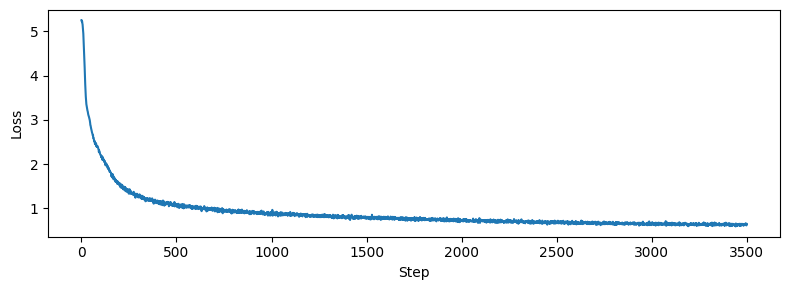

In [ ]:
# Flatten all stories into a single token stream with BOS markers as story boundaries
all_tokens = torch.tensor(
    [t for doc in docs for t in [BOS] + encode(doc)] + [BOS],
    dtype=torch.long, device=device
)

def get_batch():
    # Sample batch_size random windows of block_size tokens from the stream
    s = torch.randint(0, len(all_tokens) - block_size - 1, (batch_size,), device=device)
    idx = s.unsqueeze(1) + torch.arange(block_size + 1, device=device)
    t = all_tokens[idx]
    return t[:, :-1], t[:, 1:]  # inputs, targets (shifted by 1 for next-token prediction)

# ── Optimizer: AdamW ─────────────────────────────────────────────────────────
num_steps  = 3500   # total training steps
warmup     = 200    # steps to linearly ramp LR up from 0 (stabilises early training)
lr         = 1e-3   # peak learning rate
min_lr     = 1e-4   # 10% of peak — prevents wasted steps at tail

def get_lr(step):
    # Linear warmup then cosine decay to min_lr floor
    if step < warmup:
        return lr * step / warmup
    p = (step - warmup) / (num_steps - warmup)
    return min_lr + (lr - min_lr) * 0.5 * (1 + math.cos(math.pi * p))

opt = torch.optim.AdamW(params, lr=lr, betas=(0.9, 0.95), eps=1e-10, fused=(device.type == 'cuda'))
scaler = torch.amp.GradScaler('cuda')  # scales loss to prevent float16 gradient underflow
losses, t0 = [], time.time()

for step in range(num_steps + 1):
    opt.param_groups[0]['lr'] = get_lr(step)  # update LR each step
    if step % 100 == 0:
        xb, yb = get_batch()
        with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
            loss_val = F.cross_entropy(forward(xb).reshape(-1, vocab_size), yb.reshape(-1)).item()
        print(f"step {step:4d}/{num_steps} | loss {loss_val:.4f} | lr {get_lr(step):.2e} | {time.time()-t0:.1f}s")
    if step >= num_steps: break
    opt.zero_grad(set_to_none=True)
    xb, yb = get_batch()
    with torch.amp.autocast('cuda', dtype=torch.float16):
        loss = F.cross_entropy(forward(xb).reshape(-1, vocab_size), yb.reshape(-1))
    scaler.scale(loss).backward()
    scaler.unscale_(opt)
    torch.nn.utils.clip_grad_norm_(params, 1.0)  # prevent loss spikes from large gradients
    scaler.step(opt); scaler.update()
    losses.append(loss.item())

print(f"\nDone in {time.time()-t0:.1f}s")
plt.figure(figsize=(8, 3))
plt.plot(losses); plt.xlabel('Step'); plt.ylabel('Loss'); plt.tight_layout(); plt.show()

## 6. Inference and Text Generation

In [ ]:
num_samples    = 5    # number of stories to generate
max_new_tokens = 200  # max characters per story (stops early if BOS token is predicted)
temperature    = 0.7  # lower = more focused, higher = more random

def generate(max_tokens=200, temperature=0.7):
    tokens = [BOS]
    with torch.no_grad():
        for _ in range(max_tokens):
            x = torch.tensor([tokens[-block_size:]], device=device)  # sliding window context
            logits = forward(x)[0, -1, :vocab_size]
            next_id = torch.multinomial(F.softmax(logits / temperature, -1), 1).item()
            if next_id == BOS: break  # end of story
            tokens.append(next_id)
    return decode(tokens[1:])

t0 = time.time()
for i in range(num_samples):
    print(f"--- sample {i+1} ---\n{generate(max_new_tokens, temperature)}\n")
print(f"Done in {time.time()-t0:.1f}s")

--- sample 1 ---
Once upon a time, there was a big girl named Amy. She loved to talk and see her big brother. One day, she found a shiny gem in the chair. She was very happy to have a plan to see the girl. She was ver

--- sample 2 ---
Once upon a time, there was a little girl named Amy. She loved to play with her toy cars. One day, she went to the farm with her mom. She saw a big shell near the stream. The street was a friendly and

--- sample 3 ---
One day, a little boy named Tim went to introduce his room. He liked to run and jump, and play with his friends. They were very happy.
But soon, they decided to make a funny house. Tim was happy becau

--- sample 4 ---
One day, a little boy named Tim went to the park. He saw a big red ball with everywhere. Tim was very excited to play with the ball together. They lifted the ball and drank the sack.
Tim said to the l

--- sample 5 ---
Once upon a time, there was a little boy named Tim. He loved to march everyday. One day, he found a big box